# 1.基于 CNN + SELU 激活函数的图像分类模型

本章使用 PyTorch 构建一个卷积神经网络（CNN），采用 **SELU（Scaled Exponential Linear Unit）** 自归一化激活函数替代传统 ReLU，在图像分类任务中实现更稳定的梯度传播与更快的收敛速度。

**主要内容：**
- 数据集加载与预处理
- CNN + SELU 网络架构设计
- 模型训练、验证与评估
- 使用 TensorBoard 可视化训练过程

## 一、导入依赖库与环境配置

In [1]:
import matplotlib as mpl              # 导入 matplotlib 绘图库（底层配置）
import matplotlib.pyplot as plt       # 导入 pyplot 子模块，提供类似 MATLAB 的绘图接口
%matplotlib inline                    
# 魔法命令：使图像直接嵌入 notebook 中显示
import numpy as np                    # 导入 NumPy，提供高性能数值计算与多维数组支持
import sklearn                        # 导入 scikit-learn，提供机器学习评估指标等工具
import pandas as pd                   # 导入 Pandas，提供 DataFrame 等数据处理结构
import os                             # 导入 os 模块，用于文件系统路径操作（创建目录等）
import sys                            # 导入 sys 模块，用于获取 Python 解释器信息
import time                           # 导入 time 模块，可用于计时操作
from tqdm import tqdm            # 导入 tqdm 进度条库，自动适配 notebook/终端环境
import torch                          # 导入 PyTorch 深度学习框架（张量计算、自动微分）
import torch.nn as nn                 # 导入 nn 模块，包含神经网络层、损失函数、容器等
import torch.nn.functional as F       # 导入函数式 API，包含激活函数（relu/selu）等无状态操作

print(sys.version_info)               # 打印 Python 版本详细信息（major/minor/micro 等字段）
for module in mpl, np, pd, sklearn, torch:   # 遍历需要检查版本的各个库
    print(module.__name__, module.__version__)  # 打印库名及其版本号，便于环境复现

# 检测是否有可用 GPU，优先使用第 0 块 GPU（cuda:0），否则回退到 CPU
# torch.cuda.is_available() 返回 bool，True 表示 CUDA 可用
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)   # 打印当前使用的计算设备（cuda:0 或 cpu）

seed = 42       # 全局随机种子，用于保证数据集划分、权重初始化等操作的可复现性


sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


## 二、数据准备

### 2.1 加载 FashionMNIST 数据集

In [2]:
from torchvision import datasets                 # 导入 torchvision 内置数据集模块，包含 FashionMNIST 等常用数据集
from torchvision.transforms import ToTensor     # 导入 ToTensor 变换：将 PIL 图像或 ndarray 转为 float Tensor 并归一化到 [0,1]
from torch.utils.data import random_split       # 导入 random_split：按指定大小随机划分数据集

# 加载 FashionMNIST 训练集（共 60000 张 28x28 灰度图，10 个服装类别）
# root="data"      : 数据集本地存储根目录，不存在时自动创建
# train=True       : 加载训练集（60000 张）；False 时加载测试集（10000 张）
# download=True    : 若本地不存在则自动从网络下载数据集
# transform=ToTensor(): 将像素值从 uint8 [0,255] 转换为 float32 [0,1] 的 Tensor，形状 [1,28,28]
train_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

# 加载 FashionMNIST 测试集（共 10000 张），参数含义同上，train=False 表示加载测试集
test_ds = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

# torchvision 数据集本身不提供训练集/验证集的划分
# 使用 random_split 将 60000 张训练图按 55000:5000（约 11:1）划分为训练集和验证集
# [55000, 5000]                          : 各子集的样本数量列表，之和必须等于原数据集总量
# torch.Generator().manual_seed(seed)    : 固定随机生成器种子，确保每次划分结果一致
train_ds, val_ds = random_split(train_ds, [55000, 5000], torch.Generator().manual_seed(seed))

### 2.2 计算均值方差与数据标准化变换

In [3]:
from torchvision.transforms import Normalize  # 导入 Normalize 变换，对图像各通道执行 Z-score 标准化
# Normalize 接口说明:
#   类路径: torchvision.transforms.Normalize
#   功能  : 对输入 Tensor 的每个通道 c 执行线性标准化：output[c] = (input[c] - mean[c]) / std[c]
#           将像素值从任意范围映射为近似均值为 0、方差为 1 的分布，有助于加速梯度下降收敛
#   参数  :
#     mean (sequence of float): 每个通道的均值列表，长度等于通道数 C
#                               例如单通道灰度图传入 [0.2856]，RGB 三通道传入 [R均值, G均值, B均值]
#     std  (sequence of float): 每个通道的标准差列表，长度等于通道数 C，不可为 0
#                               例如单通道传入 [0.3202]
#     inplace (bool, 可选)    : 是否原地修改输入 Tensor，默认 False（返回新 Tensor）
#   调用  : normalize_obj(tensor) —— tensor 形状为 [C, H, W] 或 [B, C, H, W]
#   返回值: 与输入形状、dtype 完全相同的 float Tensor，数值已完成标准化
#           例如输入像素值范围 [0.0, 1.0]（单通道 FashionMNIST），
#           标准化后值域约为 [-0.89, +2.23]（均值像素→0.0，最暗→-0.89，最亮→+2.23）
#   注意  : Normalize 本身不是 nn.Module，需用 nn.Sequential 包裹后才能注册为子模块，
#           随 model.to(device) 一同迁移至 GPU，在 GPU 上执行标准化运算
#
# 不包裹 nn.Sequential 时的两种独立用法:
#   用法一 —— 在 DataLoader 的 transform 参数中使用（CPU 预处理，数据加载阶段执行）:
#     datasets.FashionMNIST(..., transform=Compose([ToTensor(), Normalize([mean], [std])]))
#     此时 Normalize 作为数据集变换管道的一环，在 CPU 上对每张图执行标准化，
#     无需注册为 nn.Module，但标准化发生在数据加载阶段而非 GPU 前向传播阶段
#
#   用法二 —— 直接实例化后像函数一样调用（临时/一次性变换）:
#     norm = Normalize([mean], [std])   # 实例化变换对象
#     x_normed = norm(x)                # 直接调用，x 为 Tensor[C,H,W] 或 [B,C,H,W]
#     此写法适合在脚本中对单个 Tensor 做临时变换，不涉及模型注册，
#     若 x 在 GPU 上则变换也在 GPU 执行，但无法随模型 .to(device) 自动迁移
#
# 本代码选择 nn.Sequential 包裹是为了将标准化纳入模型内部，
# 统一由 model.to(device) 管理设备迁移，并在 GPU 上与卷积层流水线式执行

# 计算数据集每个通道的均值和标准差，用于后续 Normalize 变换的参数设置
# 参数:
#   ds: 数据集对象（可迭代），每个元素为 (img_tensor, label)
#       img_tensor 形状为 [C, H, W]（通道数, 高, 宽）
# 返回值:
#   mean (Tensor): 各通道的均值，形状 [C]
#   std  (Tensor): 各通道的标准差，形状 [C]
def cal_mean_std(ds):
    mean = 0.  # 初始化均值累加器（标量，广播到各通道）
    std = 0.   # 初始化标准差累加器
    for img, _ in ds:                    # 遍历数据集，img: Tensor[C,H,W]，标签用 _ 忽略
        mean += img.mean(dim=(1, 2))     # 对 H（dim=1）和 W（dim=2）维度求均值，累加各通道值
        std += img.std(dim=(1, 2))       # 对 H 和 W 维度求标准差，累加各通道值
    mean /= len(ds)  # 除以数据集样本总数，得到所有样本的通道均值
    std /= len(ds)   # 除以数据集样本总数，得到所有样本的通道标准差
    return mean, std  # 返回 (均值 Tensor, 标准差 Tensor)

mean_ds, std_ds = cal_mean_std(train_ds)
mean_ds = mean_ds.item() 
std_ds= std_ds.item()
print(mean_ds,std_ds)


# 构建图像标准化变换序列（nn.Sequential 可串联多个变换模块）
# Normalize(mean, std) 对每个通道执行: output = (input - mean) / std
# 使用预计算的均值 [0.2856] 和标准差 [0.3202]（列表长度对应通道数，FashionMNIST 为单通道）
transforms = nn.Sequential(
    Normalize([mean_ds], [std_ds])  # 将像素值从 [0,1] 标准化为均值为 0、方差为 1 的分布
)  # 标准化后可加速训练收敛，减少不同特征量纲的影响

0.28556734323501587 0.32018065452575684


### 2.3 创建 DataLoader

In [4]:
from torch.utils.data.dataloader import DataLoader  # 导入 DataLoader：将数据集封装为可迭代的批次加载器

batch_size = 32  # 批量大小：每次迭代送入模型的样本数；较小值节省显存，较大值加速训练但需更多显存

# 创建训练集 DataLoader
# dataset=train_ds : 数据来源，训练集（55000 张）
# batch_size       : 每批样本数，即每次返回 32 张图像和对应标签
# shuffle=True     : 每个 epoch 开始前随机打乱样本顺序，防止模型记忆样本顺序，提升泛化能力
# num_workers=4    : 使用 4 个子进程并行预加载数据，减少 GPU 等待 CPU 的时间
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4)

# 创建验证集 DataLoader
# shuffle=False : 验证时无需打乱，保证评估结果一致且可复现
val_loader = DataLoader(val_ds, batch_size=batch_size*2, shuffle=False, num_workers=4)

# 创建测试集 DataLoader
# shuffle=False : 测试集按固定顺序加载，便于与基准结果对比
test_loader = DataLoader(test_ds, batch_size=batch_size*2, shuffle=False, num_workers=4)

## 三、定义模型

### 3.1 定义 CNN 卷积神经网络模型

In [5]:
# 定义卷积神经网络（CNN）模型类，继承自 nn.Module（PyTorch 所有神经网络的基类）
class CNN(nn.Module):
    # 构造函数：初始化网络各层
    # 参数:
    #   activation (str): 激活函数选择，"relu" 使用 ReLU，其他值使用 SELU（自归一化激活函数）
    #                     默认使用 "selu"，与 LeCun 初始化配合可实现自归一化特性
    def __init__(self, activation="selu"):
        super(CNN, self).__init__()   # 调用父类 nn.Module 的构造函数，完成必要的内部初始化
        # 根据参数选择激活函数：F.relu 或 F.selu（SELU 具有自归一化特性，无需 BatchNorm）
        self.activation = F.relu if activation == "relu" else F.selu
        # 将外部定义的 transforms（nn.Sequential 子模块）注册为模型属性
        # 注册后会自动成为子模块，model.to(device) 时随模型一同迁移到目标设备
        # transforms 包含 Normalize([0.2856], [0.3202])，将输入归一化为均值≈0、方差≈1
        # 这是 SELU 自归一化性质的必要前提：网络每层输入需近似服从标准正态分布
        self.transforms = transforms
        # 卷积层1: in_channels=1（灰度图单通道）, out_channels=32（生成32个特征图）
        #          kernel_size=3（3×3卷积核）, padding=1（边缘填充1像素，保持特征图尺寸不变）
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        # 卷积层2: 输入32通道，输出32通道，尺寸保持不变
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        # 最大池化层: kernel_size=2, stride=2，将特征图长宽各缩小一半（28→14→7→3）
        self.pool = nn.MaxPool2d(2, 2)
        # 卷积层3: 输入32通道，输出64通道，提取更高层次的特征
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # 卷积层4: 输入64通道，输出64通道
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        # 卷积层5: 输入64通道，输出128通道
        self.conv5 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        # 卷积层6: 输入128通道，输出128通道
        self.conv6 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        # 展平层: 将形状 [batch, 128, 3, 3] 的张量展平为 [batch, 128*3*3=1152] 的一维向量
        self.flatten = nn.Flatten()
        # 全连接层1: 输入特征数=128*3*3=1152（28×28 经过3次步长2的池化后尺寸为3×3）
        #            输出特征数=128
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        # AlphaDropout: 专为 SELU 自归一化激活函数设计的 Dropout 变体
        # 接口说明:
        #   类路径: torch.nn.AlphaDropout
        #   功能  : 在训练阶段以概率 p 随机将神经元输出置为一个特殊负值（而非 0），
        #           并对剩余神经元进行仿射变换（乘以缩放因子 a、加上偏移量 b），
        #           使 Dropout 后的输出仍保持均值≈0、方差≈1 的标准正态分布，
        #           从而与 SELU 的自归一化性质完美兼容，防止引入额外的方差漂移。
        #           普通 Dropout 直接置 0 会破坏 SELU 的均值/方差守恒，故不适用。
        #   参数  :
        #     p    (float, 默认=0.5): 神经元被"失活"的概率，取值范围 [0, 1)
        #                             p=0.5 表示训练时约一半神经元被随机屏蔽，起到正则化效果
        #     inplace (bool, 默认=False): 是否原地修改输入 Tensor
        #   调用  : alpha_dropout(x)  ——  x 为 Tensor，形状任意
        #   返回值: 与输入形状、dtype 相同的 Tensor；
        #           训练模式（model.train()）下随机屏蔽并仿射变换；
        #           推理模式（model.eval()）下直接返回输入，不做任何处理
        #   适用范围: 仅在 SELU 激活函数之后使用，配合 LeCun Normal 初始化共同维持自归一化链条
        self.alpha_dropout = nn.AlphaDropout(p=0.65)
        # 全连接层2（分类输出层）: 输入128，输出10（对应 FashionMNIST 的10个类别）
        self.fc2 = nn.Linear(128, 10)

        self.init_weights()  # 在构造时立即调用权重初始化方法

    def init_weights(self):
        """使用 LeCun Normal 初始化全连接层、卷积层的权重 W
        
        LeCun Normal: std = sqrt(1 / fan_in)，是 SELU 自归一化性质的理论前提之一。
        PyTorch 中通过 kaiming_normal_(mode='fan_in', nonlinearity='linear') 实现：
          - mode='fan_in'       : 只考虑输入连接数（fan_in），等价于 LeCun 公式
          - nonlinearity='linear': 增益系数取 1（线性激活），与 LeCun Normal 定义一致
        """
        # 遍历模型所有子模块（包括嵌套模块）
        for m in self.modules():
            # 仅对全连接层（nn.Linear）和卷积层（nn.Conv2d）做权重初始化
            # 跳过 transforms 中的 Normalize（其无可训练权重）
            if isinstance(m, (nn.Linear, nn.Conv2d)):
                # LeCun Normal 初始化：std = sqrt(1/fan_in)
                # 保持前向传播各层激活值方差为 1，与 SELU 的自归一化性质配套使用
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='linear')
                # 偏置项统一初始化为 0
                nn.init.zeros_(m.bias)

    # 前向传播函数：定义数据流经网络的计算路径
    # 参数:
    #   x (Tensor): 输入图像批次，形状为 [batch_size, 1, 28, 28]，像素值范围 [0, 1]
    # 返回值:
    #   x (Tensor): 输出 logits（未归一化分类分数），形状为 [batch_size, 10]
    def forward(self, x):
        # 输入标准化：将像素值从 [0,1] 归一化为均值≈0、方差≈1 的分布
        # 满足 SELU 自归一化链条的起始条件，使第一层输出也能保持归一化分布
        x = self.transforms(x)
        act = self.activation  # 取出选定的激活函数（relu 或 selu）
        # 第一卷积块: conv1→激活→conv2→激活→池化，特征图尺寸: 28×28 → 14×14，通道: 1→32
        x = self.pool(act(self.conv2(act(self.conv1(x)))))
        # 第二卷积块: conv3→激活→conv4→激活→池化，特征图尺寸: 14×14 → 7×7，通道: 32→64
        x = self.pool(act(self.conv4(act(self.conv3(x)))))
        # 第三卷积块: conv5→激活→conv6→激活→池化，特征图尺寸: 7×7 → 3×3，通道: 64→128
        x = self.pool(act(self.conv6(act(self.conv5(x)))))
        x = self.flatten(x)                  # 展平: [batch, 128, 3, 3] → [batch, 1152]
        x = self.alpha_dropout(act(self.fc1(x)))  # 全连接层1 + SELU 激活 + AlphaDropout 正则化
        # 数据流说明: fc1 线性变换 → SELU 激活（保持自归一化均值/方差）
        #             → AlphaDropout 随机屏蔽（仿射补偿，输出仍满足均值≈0、方差≈1）
        # 训练阶段: AlphaDropout 以 p=0.5 随机置为特殊负值并执行仿射缩放，起正则化效果
        # 推理阶段: AlphaDropout 透传输入，不改变任何数值
        # 输出形状: [batch, 128]
        x = self.fc2(x)        # 全连接层2（输出层，不加激活）：[batch, 128] → [batch, 10]
        return x               # 返回原始 logits，由损失函数内部进行 Softmax 处理


# 实例化 CNN 并遍历所有命名参数，打印每层权重的名称与参数量
# named_parameters() 返回 (参数名, 参数张量) 的迭代器
# np.prod(value.shape) 计算张量各维度乘积，即参数元素总数
for idx, (key, value) in enumerate(CNN().named_parameters()):
    print(f"{key}\tparamerters num: {np.prod(value.shape)}")
print('-'*50)   
# 使用 named_modules() 打印每一层的模块名和模块类型（包括模型本身及其所有递归子模块）
# 该方法在模型调试和结构可视化时很有用，可便捷查看模型的所有组成层级和类型
# 遍历结果元组：(name, module)
#   - name   : 子模块在模型中的路径（主模块为""，子层如"conv1"、"fc1"）
#   - module : 子模块本身的实例，module.__class__.__name__ 返回其类型字符串
for name, module in CNN().named_modules():
    # 打印格式：<模块名>\tmodule: <模块类型>
    # 主模块（模型本身）name为""，其余为各自的层级名
    print(f"{name}\tmodule: {module.__class__.__name__}")

conv1.weight	paramerters num: 288
conv1.bias	paramerters num: 32
conv2.weight	paramerters num: 9216
conv2.bias	paramerters num: 32
conv3.weight	paramerters num: 18432
conv3.bias	paramerters num: 64
conv4.weight	paramerters num: 36864
conv4.bias	paramerters num: 64
conv5.weight	paramerters num: 73728
conv5.bias	paramerters num: 128
conv6.weight	paramerters num: 147456
conv6.bias	paramerters num: 128
fc1.weight	paramerters num: 147456
fc1.bias	paramerters num: 128
fc2.weight	paramerters num: 1280
fc2.bias	paramerters num: 10
--------------------------------------------------
	module: CNN
transforms	module: Sequential
transforms.0	module: Normalize
conv1	module: Conv2d
conv2	module: Conv2d
pool	module: MaxPool2d
conv3	module: Conv2d
conv4	module: Conv2d
conv5	module: Conv2d
conv6	module: Conv2d
flatten	module: Flatten
fc1	module: Linear
alpha_dropout	module: AlphaDropout
fc2	module: Linear


### 3.2 统计模型参数量

In [6]:
# 统计模型中所有可训练参数的元素总数
# 参数:
#   model (nn.Module): 任意 PyTorch 模型实例
# 返回值:
#   int: 所有 requires_grad=True 的参数张量的元素总数之和
def count_parameters(model):
    # model.parameters() 返回模型所有参数张量的迭代器
    # p.numel() 返回张量 p 的元素总数（即各维度大小的乘积）
    # requires_grad=True 筛选出需要梯度更新（即参与反向传播）的参数，排除冻结层
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

count_parameters(CNN())  # 计算并打印默认激活函数（relu）的 CNN 模型总参数量

435306

## 四、训练过程

PyTorch 的训练流程需要手动实现，主要包含以下步骤：
1. 定义损失函数
2. 定义优化器
3. 定义训练步（前向传播、反向传播、参数更新）
4. 执行训练循环

### 4.1 定义评估函数

In [7]:
from sklearn.metrics import accuracy_score  # 导入 sklearn 准确率计算函数: 正确预测数/总样本数

# @torch.no_grad() 装饰器：在函数执行期间关闭梯度计算图的构建
# 评估阶段不需要反向传播，关闭梯度可节省显存并加快推理速度
@torch.no_grad()
# 在验证集或测试集上对模型进行完整评估
# 参数:
#   model      (nn.Module)  : 处于 eval 模式的待评估模型
#   dataloader (DataLoader) : 验证集或测试集的数据加载器
#   loss_fct   (callable)   : 损失函数，如 nn.CrossEntropyLoss()
# 返回值:
#   (float, float): 元组，第一个值为所有 batch 的平均损失，第二个值为整体准确率
def evaluating(model, dataloader, loss_fct):
    loss_list = []    # 用于存储每个 batch 的标量损失值
    pred_list = []    # 用于存储所有样本的预测类别索引
    label_list = []   # 用于存储所有样本的真实类别索引
    model.eval()    # 切换为验证模式，禁用 Dropout/BN 等，仅用于推理
    for datas, labels in dataloader:         # 遍历数据加载器，每次取一个 batch
        datas = datas.to(device)             # 将图像张量移至目标设备（GPU/CPU）
        labels = labels.to(device)           # 将标签张量移至目标设备
        # 前向传播：得到形状为 [batch_size, 10] 的未归一化分类分数（logits）
        logits = model(datas)
        loss = loss_fct(logits, labels)      # 计算当前 batch 的交叉熵损失
        loss_list.append(loss.item())        # .item() 将单元素张量转为 Python float 并存储

        # argmax(axis=-1) 沿最后一个维度（类别维）取最大值的索引，即预测类别
        preds = logits.argmax(axis=-1)
        # .cpu() 将张量从 GPU 移回 CPU，.numpy() 转为 ndarray，.tolist() 转为 Python 列表
        pred_list.extend(preds.cpu().numpy().tolist())    # 追加当前 batch 预测结果
        label_list.extend(labels.cpu().numpy().tolist())  # 追加当前 batch 真实标签

    # accuracy_score(y_true, y_pred): 计算分类准确率 = 预测正确数 / 总样本数
    acc = accuracy_score(label_list, pred_list)
    return np.mean(loss_list), acc  # 返回 (各 batch 损失的算术平均值, 整体准确率)


### 4.2 TensorBoard 可视化回调

In [8]:
from torch.utils.tensorboard import SummaryWriter  # 导入 TensorBoard 事件文件写入器，用于记录训练指标


# TensorBoard 可视化回调类：封装训练指标的记录逻辑，供训练循环在每次评估时调用
class TensorBoardCallback:
    # 初始化 TensorBoard 写入器
    # 参数:
    #   log_dir    (str): TensorBoard 事件文件的存储目录，如 "runs/cnn-selu"
    #   flush_secs (int): 缓冲区每隔多少秒自动刷新（写入磁盘），默认 10 秒
    def __init__(self, log_dir, flush_secs=10):
        """
        Args:
            log_dir (str): dir to write log.
            flush_secs (int, optional): write to dsk each flush_secs seconds. Defaults to 10.
        """
        # 创建 SummaryWriter 实例：负责将标量、图像、计算图等数据写入 TensorBoard 事件文件
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    # 将模型计算图可视化写入 TensorBoard
    # 参数:
    #   model       (nn.Module): 要可视化计算图结构的模型
    #   input_shape (list)     : 示例输入张量的形状，如 [1, 1, 28, 28]（batch=1, C=1, H=28, W=28）
    def draw_model(self, model, input_shape):
        # add_graph 接受模型和示例输入，追踪前向传播并记录计算图结构
        # torch.randn(input_shape) 生成标准正态分布随机张量作为示例输入
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))

    # 同时记录训练损失和验证损失到同一张 TensorBoard 图表中
    # 参数:
    #   step     (int)  : 当前全局步数，作为 X 轴坐标
    #   loss     (float): 当前步训练集损失值
    #   val_loss (float): 当前步验证集损失值
    def add_loss_scalars(self, step, loss, val_loss):
        self.writer.add_scalars(
            main_tag="training/loss",                              # 图表分组路径和名称
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},  # 要记录的指标键值对
            global_step=step,                                      # X 轴步数
            )

    # 同时记录训练准确率和验证准确率到同一张 TensorBoard 图表中
    # 参数:
    #   step    (int)  : 当前全局步数
    #   acc     (float): 当前步训练集准确率
    #   val_acc (float): 当前步验证集准确率
    def add_acc_scalars(self, step, acc, val_acc):
        self.writer.add_scalars(
            main_tag="training/accuracy",                                   # 图表路径和名称
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},     # 要记录的指标键值对
            global_step=step,                                               # X 轴步数
        )

    # 记录当前学习率到 TensorBoard，便于监控学习率调度效果
    # 参数:
    #   step          (int)  : 当前全局步数
    #   learning_rate (float): 当前步的学习率值
    def add_lr_scalars(self, step, learning_rate):
        self.writer.add_scalars(
            main_tag="training/learning_rate",                    # 图表路径和名称
            tag_scalar_dict={"learning_rate": learning_rate},     # 要记录的学习率值
            global_step=step,                                     # X 轴步数
        )

    # __call__ 使实例可像函数一样被调用，统一处理各类指标的记录逻辑
    # 参数:
    #   step     (int)   : 当前全局步数
    #   **kwargs (dict)  : 可选关键字参数，支持 loss, val_loss, acc, val_acc, lr
    def __call__(self, step, **kwargs):
        # 提取损失值（pop 在获取值的同时将键从字典中移除，避免干扰后续处理）
        loss = kwargs.pop("loss", None)        # 训练损失，默认 None
        val_loss = kwargs.pop("val_loss", None)  # 验证损失，默认 None
        if loss is not None and val_loss is not None:  # 两者均存在时才记录损失图表
            self.add_loss_scalars(step, loss, val_loss)
        # 提取准确率值
        acc = kwargs.pop("acc", None)          # 训练准确率，默认 None
        val_acc = kwargs.pop("val_acc", None)  # 验证准确率，默认 None
        if acc is not None and val_acc is not None:    # 两者均存在时才记录准确率图表
            self.add_acc_scalars(step, acc, val_acc)
        # 提取学习率值
        learning_rate = kwargs.pop("lr", None)  # 学习率，默认 None
        if learning_rate is not None:            # 存在时才记录学习率图表
            self.add_lr_scalars(step, learning_rate)


### 4.3 保存最优权重回调


In [9]:
# 模型权重保存回调类：在训练过程中按验证步保存检查点，支持只保存最优模型
class SaveCheckpointsCallback:
    # 初始化保存配置
    # 参数:
    #   save_dir      (str) : 检查点文件的保存目录路径
    #   save_best_only(bool): True 时只在验证指标创历史最优时保存；False 时每次都保存
    def __init__(self, save_dir, save_best_only=True):
        """
        Save checkpoints each save_epoch epoch. 
        We save checkpoint by epoch in this implementation.
        Usually, training scripts with pytorch evaluating model and save checkpoint by step.

        Args:
            save_dir (str): dir to save checkpoint
            save_epoch (int, optional): the frequency to save checkpoint. Defaults to 1.
            save_best_only (bool, optional): If True, only save the best model or save each model at every epoch.
        """
        self.save_dir = save_dir              # 存储检查点文件的目录
        self.save_best_only = save_best_only  # 是否只保存验证指标最优的模型
        self.best_metrics = -1                # 历史最优验证指标，初始化为 -1（确保第一次必定保存）

        # 若保存目录不存在，则自动创建（os.mkdir 只能创建一级目录）
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)

    # __call__ 使实例可像函数一样被调用，在训练循环中每个评估步触发
    # 参数:
    #   step       (int)  : 当前全局训练步数
    #   state_dict (dict) : 模型权重字典，由 model.state_dict() 获取，键为层名，值为权重张量
    #   metric     (float): 当前步的验证集评估指标（如准确率），save_best_only=True 时必须提供
    def __call__(self, step, state_dict, metric=None):
        if self.save_best_only:
            assert metric is not None  # 断言：save_best_only=True 时必须提供 metric 参数
            if metric >= self.best_metrics:       # 当前指标优于或等于历史最优时才保存
                # 将模型权重字典序列化并保存为 best.ckpt 文件
                # os.path.join 拼接目录和文件名，兼容不同操作系统的路径分隔符
                torch.save(state_dict, os.path.join(self.save_dir, "1_model_best.ckpt"))
                self.best_metrics = metric        # 更新历史最优指标记录
        else:
            # 非仅保存最优模式：以步数命名文件，保存按验证步间隔的每个检查点（会占用更多磁盘空间）
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))



### 4.4 早停回调

In [10]:
# 早停回调类：当验证集指标在连续多次评估中无显著提升时，触发早停以防止过拟合
class EarlyStopCallback:
    # 初始化早停超参数
    # 参数:
    #   patience  (int)  : 允许连续无提升的最大评估次数，超过后触发早停，默认 5 次
    #   min_delta (float): 最小有效提升阈值；指标变化量小于此值视为"无提升"，默认 0.01
    def __init__(self, patience=5, min_delta=0.01):
        """

        Args:
            patience (int, optional): Number of epochs with no improvement after which training will be stopped.. Defaults to 5.
            min_delta (float, optional): Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute 
                change of less than min_delta, will count as no improvement. Defaults to 0.01.
        """
        self.patience = patience      # 最大无提升容忍次数
        self.min_delta = min_delta    # 最小有效提升阈值
        self.best_metric = -1         # 历史最优指标值，初始化为 -1（确保第一次必定视为提升）
        self.counter = 0              # 连续无提升的计数器

    # __call__ 每次评估后调用，传入当前验证集指标值，更新计数器状态
    # 参数:
    #   metric (float): 当前评估步的验证集指标值（如准确率），越高越好
    def __call__(self, metric):
        # 当前指标比历史最优提升超过 min_delta 时，视为有效提升
        if metric >= self.best_metric + self.min_delta:
            self.best_metric = metric  # 更新历史最优指标
            self.counter = 0           # 重置无提升计数器（有提升则清零）
        else:
            self.counter += 1          # 无有效提升，计数器加 1

    # 属性方法（@property）：无需括号即可像属性一样访问，判断是否达到早停条件
    # 返回值: bool - counter >= patience 时返回 True，表示应当停止训练
    @property
    def early_stop(self):
        return self.counter >= self.patience  # 连续无提升次数达到上限时，触发早停


### 4.5 训练函数与执行训练

In [11]:
# 完整训练函数：封装训练循环、验证评估、回调触发等核心训练逻辑
# 参数:
#   model                  (nn.Module)             : 待训练的模型
#   train_loader           (DataLoader)             : 训练集数据加载器
#   val_loader             (DataLoader)             : 验证集数据加载器
#   epoch                  (int)                    : 最大训练轮次（每轮遍历一次完整训练集）
#   loss_fct               (callable)               : 损失函数，如 nn.CrossEntropyLoss()
#   optimizer              (torch.optim.Optimizer)  : 参数优化器，如 SGD/Adam
#   tensorboard_callback   (TensorBoardCallback)    : TensorBoard 可视化回调，None 表示不使用
#   save_ckpt_callback     (SaveCheckpointsCallback): 权重保存回调，None 表示不使用
#   early_stop_callback    (EarlyStopCallback)      : 早停回调，None 表示不使用
#   eval_step              (int)                    : 每隔多少步进行一次验证集评估，默认 500
# 返回值:
#   record_dict (dict): 包含 "train" 和 "val" 两个键，各自对应每步的 loss/acc/step 记录列表
def training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=None,
    save_ckpt_callback=None,
    early_stop_callback=None,
    eval_step=500,
    ):
    # 初始化训练记录字典，分别存储训练集和验证集的逐步指标
    record_dict = {
        "train": [],  # 每步存储: {"loss": float, "acc": float, "step": int}
        "val": []     # 每个 eval_step 存储: {"loss": float, "acc": float, "step": int}
    }

    global_step = 0   # 全局步数计数器（每处理一个 batch 加 1）
    model.train()     # 切换为训练模式：启用 Dropout 随机失活和 BatchNorm 使用批统计量
    # 用 tqdm 包裹训练循环，total=总步数，实时显示训练进度、速度和自定义后缀信息
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):          # 外层循环：遍历所有 epoch
            for datas, labels in train_loader: # 内层循环：遍历训练集所有 batch
                datas = datas.to(device)       # 将图像数据移至目标设备（GPU/CPU）
                labels = labels.to(device)     # 将标签移至目标设备

                optimizer.zero_grad()          # 梯度清零：清除上一步累积的梯度，防止错误叠加
                logits = model(datas)          # 前向传播：计算预测 logits，形状 [batch, 10]
                loss = loss_fct(logits, labels)  # 计算交叉熵损失（内含 Softmax 操作）
                loss.backward()                # 反向传播：根据损失计算各参数的梯度
                optimizer.step()               # 参数更新：按梯度方向（含动量修正）调整权重

                # 取 logit 最大值对应的类别索引作为预测结果，形状 [batch]
                preds = logits.argmax(axis=-1)
                # 计算当前 batch 的训练准确率（需转回 CPU 和 numpy 供 sklearn 使用）
                acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())
                loss = loss.cpu().item()       # 将损失张量转为 Python 标量（脱离计算图）

                # 将当前步的训练指标记录到列表中
                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                })

                # 每隔 eval_step 步对验证集进行一次完整评估
                if global_step % eval_step == 0:
                    # 在验证集上计算平均损失和准确率
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    model.train()  # 评估完成后立即切回训练模式

                    # 1. TensorBoard 可视化：将当前步的所有指标写入日志
                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step,
                            loss=loss, val_loss=val_loss,              # 损失值
                            acc=acc, val_acc=val_acc,                  # 准确率
                            lr=optimizer.param_groups[0]["lr"],        # 当前学习率（从优化器获取）
                            )

                    # 2. 保存模型权重：按 save_step 频率判断是否保存检查点
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)

                    # 3. 早停检查：传入当前验证准确率，更新无提升计数器
                    if early_stop_callback is not None:
                        early_stop_callback(val_acc)
                        if early_stop_callback.early_stop:  # 若连续无提升次数达到 patience
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict  # 提前返回，终止训练

                global_step += 1               # 全局步数加 1
                pbar.update(1)                 # 进度条前进 1 格
                pbar.set_postfix({"epoch": epoch_id})  # 在进度条右侧显示当前 epoch 编号

    return record_dict  # 正常完成所有 epoch 后返回完整训练记录


epoch = 50         # 最大训练轮次：整个训练集最多被遍历 50 次

model = CNN()  # 实例化 CNN 模型，激活函数为 SELU

# 1. 定义损失函数：交叉熵损失（适用于多分类问题）
# nn.CrossEntropyLoss() 内部等价于 Softmax + NLLLoss，无需在模型输出层单独加 Softmax
loss_fct = nn.CrossEntropyLoss()

# 2. 定义优化器：随机梯度下降（SGD）带动量
# model.parameters() : 传入所有可训练参数
# lr=0.001           : 初始学习率，控制每次参数更新的步长大小
# momentum=0.9       : 动量系数，加速收敛并抑制梯度方向震荡
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# # 1. 初始化 TensorBoard 可视化回调
# if not os.path.exists("tensorboard_logs"):
#     os.mkdir("tensorboard_logs")  # 若日志根目录不存在则创建
# tensorboard_callback = TensorBoardCallback(f"tensorboard_logs/cnn_selu+lecun")  # 日志存入对应子目录
# tensorboard_callback.draw_model(model, [1, 1, 28, 28])  # 记录模型结构（batch=1, C=1, H=28, W=28）

# 2. 初始化模型权重保存回调
if not os.path.exists("model_checkpoints"):
    os.makedirs("model_checkpoints")  # makedirs 支持递归创建多级目录
# save_best_only=True：只在验证准确率创历史新高时覆盖保存 best.ckpt
save_ckpt_callback = SaveCheckpointsCallback(f"model_checkpoints/1_model", save_best_only=True)

# 3. 初始化早停回调：连续 10 次评估无显著提升则停止训练
early_stop_callback = EarlyStopCallback(patience=10)

model = model.to(device)  # 将模型所有参数和缓冲区迁移到目标设备（GPU/CPU）
eval_step=len(train_loader)//2          #设置验证步；每半epoch评估一次验证集

# 启动训练循环
record = training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=None,              # 本次不使用 TensorBoard（传 None 跳过）
    save_ckpt_callback=save_ckpt_callback,  # 使用保存最优权重回调
    early_stop_callback=early_stop_callback,  # 使用早停回调
    eval_step=eval_step                          # 每半epoch评估一次验证集，触发一次回调流
    )

 27%|██▋       | 23193/85950 [04:49<04:18, 242.97it/s, epoch=13] 

Early stop at epoch 13 / global_step 23193


 27%|██▋       | 23193/85950 [04:52<13:11, 79.31it/s, epoch=13] 


### 4.6 绘制学习曲线

In [12]:
sample_step=eval_step//2                        #训练集降采样步数；设置为验证步的一半，保持合理密度

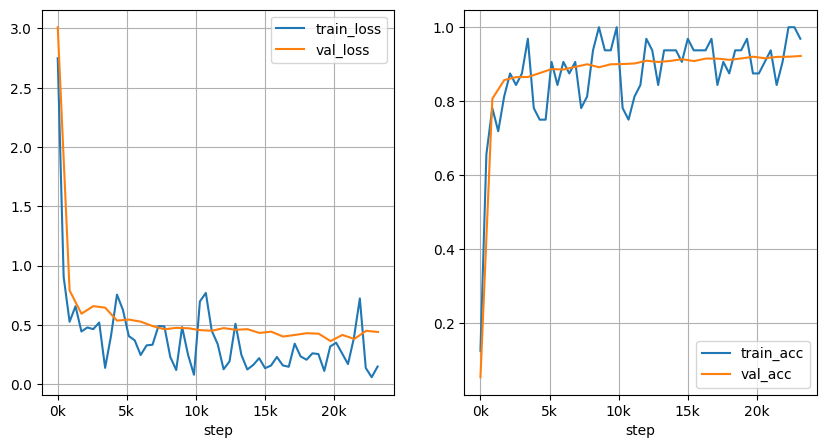

In [13]:
# 注意：损失值（loss）不一定在 [0, 1] 范围内，Y 轴范围由数据自适应决定，不要误认为越大越好
# 绘制训练曲线与验证曲线（包含 loss 和 accuracy 两个子图）
# 参数:
#   record_dict (dict): training() 函数返回的训练记录字典，包含 "train" 和 "val" 键
#   sample_step (int) : 训练集曲线的步数采样间隔（每隔 sample_step 个点取一个），默认 500
#                       由于训练记录每步都有，点数密集；采样可减少绘图点数、提升渲染速度
def plot_learning_curves(record_dict, sample_step=500):
    # 将训练记录列表转为 DataFrame：step 列作为行索引，loss/acc 列作为指标列
    # .iloc[::sample_step] 按 sample_step 间隔均匀采样，减少训练曲线数据密度
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    # 将验证记录列表转为 DataFrame：验证集本身每 eval_step 步记录一次，无需再采样
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    # 根据指标数量（loss、acc 等列数）确定需要绘制的子图数量
    fig_num = len(train_df.columns)
    # 创建 1 行 fig_num 列的子图布局，每个子图宽 5 英寸、高 5 英寸
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    for idx, item in enumerate(train_df.columns):   # 遍历每个指标列（loss、acc）
        # 绘制训练集曲线：X 轴为步数索引，Y 轴为对应指标值
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")
        # 绘制验证集曲线：X 轴为步数索引，Y 轴为对应指标值
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")
        axs[idx].grid()    # 添加网格线，方便读取坐标值
        axs[idx].legend()  # 添加图例，区分训练集和验证集曲线
        # 设置 X 轴刻度位置：从 0 到最后一步，每隔 5000 步一个刻度
        axs[idx].set_xticks(range(0, train_df.index[-1], 5000))
        # 将刻度数值格式化为简洁形式，如 5000 → "5k"，10000 → "10k"（除以 1000 加 'k' 后缀）
        axs[idx].set_xticklabels(map(lambda x: f"{int(x/1000)}k", range(0, train_df.index[-1], 5000)))
        axs[idx].set_xlabel("step")  # 设置 X 轴标签为 "step"（步数）

    plt.show()  # 渲染并展示所有子图

# 调用绘图函数，采样间隔为验证步的一半，横坐标单位为训练步数（steps）
plot_learning_curves(record, sample_step=sample_step)

## 五、模型评估

### 5.1 加载最优权重并评估

In [14]:
# 加载训练时保存的最优检查点权重，在测试集上进行最终性能评估

# torch.load() 反序列化检查点文件，返回模型权重字典（state_dict）
# 参数:
#   f            (str) : 检查点文件路径，由 activation 变量确定子目录（如 checkpoints/cnn-selu/best.ckpt）
#   map_location (str) : 权重加载目标设备；"cpu" 表示强制加载到 CPU，避免训练 GPU 与推理 CPU 不匹配的报错
# model.load_state_dict() 将权重字典中的参数逐一加载到模型对应层，实现权重恢复
model.load_state_dict(torch.load(os.path.join("model_checkpoints","1_model","1_model_best.ckpt"), map_location="cpu"))

model.eval()  # 切换为评估模式：关闭 Dropout，BatchNorm 使用训练时记录的运行均值/方差

# 在测试集上计算最终性能指标
# evaluating() 返回: (平均损失 float, 准确率 float)
loss, acc = evaluating(model, test_loader, loss_fct)
# 格式化打印：:.4f 保留 4 位小数，直观展示测试集损失和准确率
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")

loss:     0.4808
accuracy: 0.9205
